In [48]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
def sample_sphere(N, radius=1.0):
    """
    Sample N points uniformly from the surface of a sphere with given radius.
    """
    phi = torch.rand(N) * 2 * torch.pi  # azimuthal angle
    costheta = torch.rand(N) * 2 - 1  # cos(theta) uniformly in [-1, 1]
    theta = torch.acos(costheta)  # polar angle

    x = radius * torch.sin(theta) * torch.cos(phi)
    y = radius * torch.sin(theta) * torch.sin(phi)
    z = radius * costheta

    return torch.stack((x, y, z), dim=1)

In [50]:
N = 2000
noise = 0.1
beta=0.9
K = 400
function_type = "mexican"

m=2
X = sample_sphere(N)

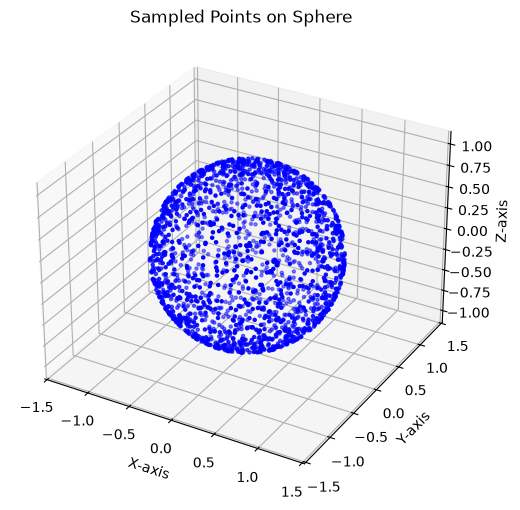

In [51]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', s=5)
ax.set_title('Sampled Points on Sphere')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.axis('equal')
plt.show()

In [52]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
# omega_true = get_omega("swiss_roll", cometric=base_cometric,dim=3)
omega_true = get_omega("circular_sphere", cometric=base_cometric,dim=3)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)
omega_true

CircularSphereOmega(
  (cometric): IdentityCoMetric(coscale=1)
)

In [53]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X)).detach()
v_true_norm = v_true.norm(dim=1)

In [54]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-16 18:20:50] - INFO - Found 22662 edges in the KNN graph.


Computing Randers distances:   0%|          | 0/227 [00:00<?, ?it/s]

Computing Randers distances: 100%|██████████| 227/227 [00:00<00:00, 3652.85it/s]


In [55]:
epsilon = compute_epsilon_empirical(dst_edges,scale=10)

W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, N, m)
c_km = -mu_1 / mu_0 * (m + 1) / m
c_km = 1 / c_km

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [56]:
# eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
# K = 2
# X_low = eigenvectors[:, :K] * eigenvalues[:K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float()


base_cometric_low = CentroidsCometric(centroids=X_low, cometric_centroids=IdentityCoMetric()(X_low))
base_cometric_low = IdentityCoMetric()

Text(0, 0.5, 'Y_low-axis')

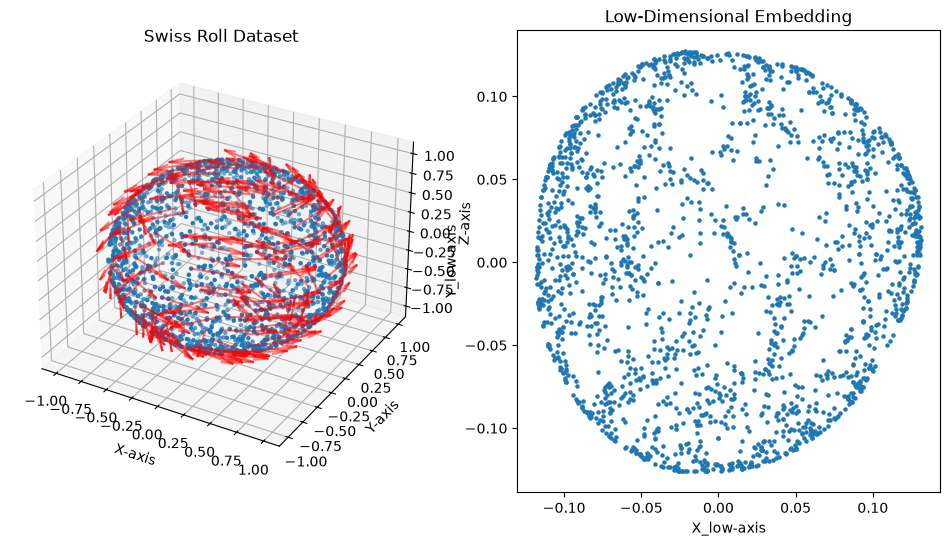

In [57]:
skip = 10
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=0.5, color='red', alpha=0.5)
           
ax1.set_title("Swiss Roll Dataset")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Z-axis")

ax2 = fig.add_subplot(122)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], s=5)
ax2.set_title("Low-Dimensional Embedding")
ax2.set_xlabel("X_low-axis")
ax2.set_ylabel("Y_low-axis")

In [62]:
# 3D interactive plot uing plotly
import plotly.graph_objects as go
fig = go.Figure(data=[go.Scatter3d(
    x=X.detach()[:, 0].numpy(),
    y=X.detach()[:, 1].numpy(),
    z=X.detach()[:, 2].numpy(),
    mode='markers',
    marker=dict(
        size=3,
        color='red',
        opacity=0.8
    )
)])
# Add quiver plot for vector field
skip = 10
fig.add_trace(go.Cone(
    x=X.detach()[::skip, 0].numpy(),
    y=X.detach()[::skip, 1].numpy(),
    z=X.detach()[::skip, 2].numpy(),
    u=b_true.detach()[::skip, 0].numpy(),
    v=b_true.detach()[::skip, 1].numpy(),
    w=b_true.detach()[::skip, 2].numpy(),
    sizemode="absolute",    
    sizeref=1,
    anchor="tail",
    showscale=False,
))


fig.update_layout(scene=dict(
                    xaxis_title='X-axis',
                    yaxis_title='Y-axis',
                    zaxis_title='Z-axis'),
                  title='Sampled Points on Sphere') 

fig

In [63]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        K, function_type, X_low, L_theta_a
    )

[2026-09-16 18:21:25] - INFO - Training vector field models...


Loss: 2.4095e-01:   0%|          | 0/1000 [00:00<?, ?it/s]

Loss: 6.5484e-05: 100%|██████████| 1000/1000 [00:02<00:00, 379.13it/s]


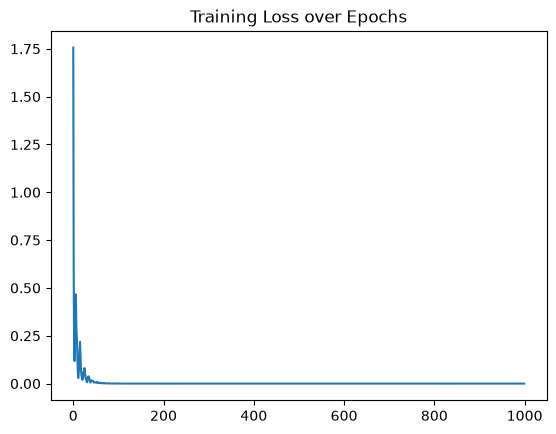

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 395.4801940917969,
 'std': 18300.01171875,
 'min': 0.0,
 'max': 10181317.0,
 'quantile_5': 21.16690444946289,
 'quantile_25': 74.13517761230469,
 'median': 104.91319274902344,
 'quantile_75': 153.75909423828125,
 'quantile_95': 557.8413696289062}

In [64]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric_low, c_km, f_values_low, Lf_values_low, f_grad_values_low
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_low, f_grad_values_low)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_low) > 1e-8, torch.abs(Lf_values_low - rhs) / torch.abs(Lf_values_low) * 100, torch.zeros_like(Lf_values_low))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [65]:
base_cometric_low.cometric(X_low,b_hat_deep_low).max() # Ptdr wtf

tensor(0.0002)

Text(0.5, 1.0, 'Learned Vector Field on Low-Dimensional Embedding')

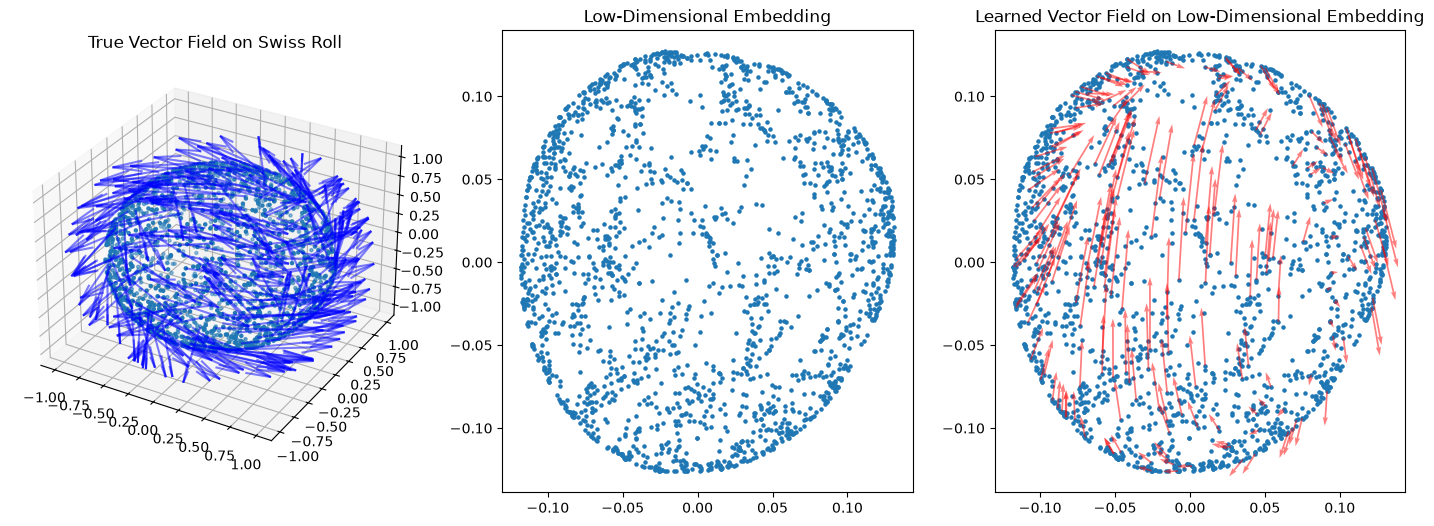

In [66]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2],  s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=1, color='blue', alpha=0.5)
ax1.set_title("True Vector Field on Swiss Roll")

ax2 = fig.add_subplot(132)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1],  s=5)
ax2.set_title("Low-Dimensional Embedding")

ax3 = fig.add_subplot(133)
ax3.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1],  s=5)
ax3.quiver(X_low.detach()[::skip, 0], X_low.detach()[::skip, 1], 
           b_hat_deep_low[::skip, 0], b_hat_deep_low[::skip, 1],
           angles='xy', scale_units='xy', scale=0.004, color='red', alpha=0.5)
ax3.set_title("Learned Vector Field on Low-Dimensional Embedding")

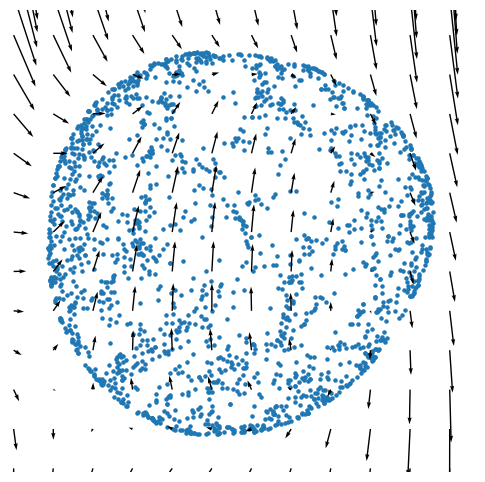

In [74]:
# Meshgrid for vector field visualization
bounds_grid = get_bounds(X_low.detach(),margin=0.4)
bounds_plts = get_bounds(X_low.detach(),margin=0.1)
x = torch.linspace(bounds_grid[0], bounds_grid[1], 20)
y = torch.linspace(bounds_grid[2], bounds_grid[3], 20)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
omega_grid = omega_model(grid_points).detach()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(),s=5)
ax.quiver(
    grid_points[:, 0].detach().cpu(),
    grid_points[:, 1].detach().cpu(),
    omega_grid[:, 0].detach().cpu(),
    omega_grid[:, 1].detach().cpu(),
    color="black",
    scale=0.01,
    # alpha=0.5,
    angles="xy",
    scale_units="xy"
)
ax.axis("off")
ax.set_xlim(bounds_plts[0], bounds_plts[1])
ax.set_ylim(bounds_plts[2], bounds_plts[3])
plt.savefig("disbm_vector_field.pdf", dpi=300, bbox_inches='tight')